# Data Analysis

## Read CSVs

In [52]:
## Libraries
import pandas as pd

## Paths
## Fashion MNIST
# complete
fashion_complete_bu_path    = "./results/fashion-7_4-complete-bu-2.csv"
fashion_td_path             = "./results/fashion-7_4-td-2.csv"


## Column Names
column_labels = [
    "Iterations",
    "CPU Time",
    "Apothem",
    "Avg Edge",
    "Max. Edge",
    "Min. Edge"
]



## Read CSVs
# Fashion MNIST
fashion_complete_bu = pd.read_csv(fashion_complete_bu_path, sep=" ",    names=column_labels)
fashion_td          = pd.read_csv(fashion_td_path,          sep=" ",    names=column_labels)

## Convert to NumPy

In [53]:
## Convert to NumPy
# Fashion MNIST
# complete
fashion_complete_bu_its         = fashion_complete_bu["Iterations"].to_numpy()
fashion_complete_bu_time        = fashion_complete_bu["CPU Time"].to_numpy()
fashion_complete_bu_apthm       = fashion_complete_bu["Apothem"].to_numpy()
fashion_complete_bu_avg_edge    = fashion_complete_bu["Avg Edge"].to_numpy()
fashion_complete_bu_max_edge    = fashion_complete_bu["Max. Edge"].to_numpy()
fashion_complete_bu_min_edge    = fashion_complete_bu["Min. Edge"].to_numpy()

# top-down
fashion_td_its                  = fashion_td["Iterations"].to_numpy()
fashion_td_time                 = fashion_td["CPU Time"].to_numpy()
fashion_td_apthm                = fashion_td["Apothem"].to_numpy()
fashion_td_avg_edge             = fashion_td["Avg Edge"].to_numpy()
fashion_td_max_edge             = fashion_td["Max. Edge"].to_numpy()
fashion_td_min_edge             = fashion_td["Min. Edge"].to_numpy()

## Pre-Processing

In [54]:
step            = 10

# top-down
td_num_iterations  = len(fashion_td_its)
td_slices          = list(range(0, td_num_iterations, step))

fashion_td_its                  = fashion_td_its[td_slices]
fashion_td_time                 = fashion_td_time[td_slices]
fashion_td_apthm                = fashion_td_apthm[td_slices]
fashion_td_avg_edge             = fashion_td_avg_edge[td_slices]
fashion_td_max_edge             = fashion_td_max_edge[td_slices]
fashion_td_min_edge             = fashion_td_min_edge[td_slices]

# complete
complete_bu_num_iterations  = len(fashion_complete_bu_its)
complete_bu_slices          = list(range(0, complete_bu_num_iterations, step))

fashion_complete_bu_its         = fashion_complete_bu_its[complete_bu_slices]
fashion_complete_bu_time        = fashion_complete_bu_time[complete_bu_slices]
fashion_complete_bu_apthm       = fashion_complete_bu_apthm[complete_bu_slices]
fashion_complete_bu_avg_edge    = fashion_complete_bu_avg_edge[complete_bu_slices]
fashion_complete_bu_max_edge    = fashion_complete_bu_max_edge[complete_bu_slices]
fashion_complete_bu_min_edge    = fashion_complete_bu_min_edge[complete_bu_slices]



## Figures

In [55]:
import matplotlib.pyplot as plt
import numpy as np

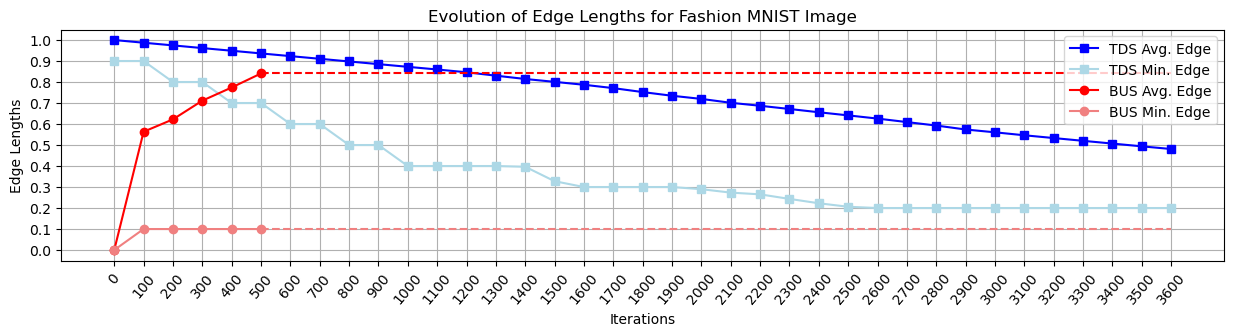

In [69]:
plt.figure(figsize=(15, 3))

# Top-Down
# plt.plot(
#     fashion_td_its,
#     fashion_td_max_edge,
#     color   = "darkblue",
#     marker  = "s",
#     label   = "TDS Max. Edge"
# )
plt.plot(
    fashion_td_its,
    fashion_td_avg_edge,
    color   = "blue",
    marker  = "s",
    label   = "TDS Avg. Edge"
)
plt.plot(
    fashion_td_its,
    fashion_td_min_edge,
    color   = "lightblue",
    marker  = "s",
    label   = "TDS Min. Edge"
)

# Complete Bottom-Up
# plt.plot(
#     fashion_complete_bu_its,
#     fashion_complete_bu_max_edge,
#     color   = "darkred",
#     marker  = "o",
#     label   = "BUS Max. Edge"
# )
plt.plot(
    fashion_complete_bu_its,
    fashion_complete_bu_avg_edge,
    color   = "red",
    marker  = "o",
    label   = "BUS Avg. Edge"
)
rest_its = list(range(500, 3700, 100))
plt.plot(
    rest_its,
    [fashion_complete_bu_avg_edge[-1]] * len(rest_its),
    color       = "red",
    #marker      = "o",
    linestyle   = "--",
)

plt.plot(
    fashion_complete_bu_its,
    fashion_complete_bu_min_edge, 
    color   = "lightcoral",
    marker  = "o",
    label   = "BUS Min. Edge"
)
plt.plot(
    rest_its,
    [fashion_complete_bu_min_edge[-1]] * len(rest_its),
    color       = "lightcoral",
    #marker      = "o",
    linestyle   = "--",
)

plt.title("Evolution of Edge Lengths for Fashion MNIST Image")
plt.xlabel("Iterations")
plt.ylabel("Edge Lengths")

# plt.axis([0, 100, 0.0, 1.0])
plt.xticks(fashion_td_its, rotation=50)
plt.yticks(list(np.arange(0.0, 1.1, 0.1)))

plt.grid(True)
plt.legend(loc="upper right")
plt.show()